# Let's try something a bit unconventional...GNN time
### Disclaimer: This is a training exercise, I understand that I'm using a model to predict something that is completely fabricated by me


In [266]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch_geometric.transforms as T
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from collections import Counter
from torch_geometric.data import InMemoryDataset, Data
import torch_geometric
from torch_geometric.nn import GATv2Conv
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [267]:
# Load the data
nodes_gnn = gpd.read_file('nodes_PC.geojson')
edges_gnn = gpd.read_file('edges_PC.geojson')

Skipping field highway: unsupported OGR type: 5
Skipping field lanes: unsupported OGR type: 5
Skipping field maxspeed: unsupported OGR type: 5
Skipping field name: unsupported OGR type: 5
Skipping field ref: unsupported OGR type: 5
Skipping field width: unsupported OGR type: 5


In [271]:
# Check the data
nodes_gnn.head()

,osmid,y,x,street_count,highway,railway,bc,traffic_lights,geometry
0,92972680,4.989948e+06,552165.187881,3,None,None,0.019900,False,POINT (5.52e+05 4.99e+06)
1,298033861,4.989172e+06,557606.802876,3,motorway_junction,None,0.019896,False,POINT (5.58e+05 4.99e+06)
2,92972786,4.987842e+06,559716.452461,3,motorway_junction,None,0.000000,False,POINT (5.6e+05 4.99e+06)
3,92975190,4.988249e+06,559443.398421,3,None,None,0.001912,False,POINT (5.59e+05 4.99e+06)
4,462186611,4.990028e+06,558166.848537,3,None,None,0.000000,False,POINT (5.58e+05 4.99e+06)


<Axes: >

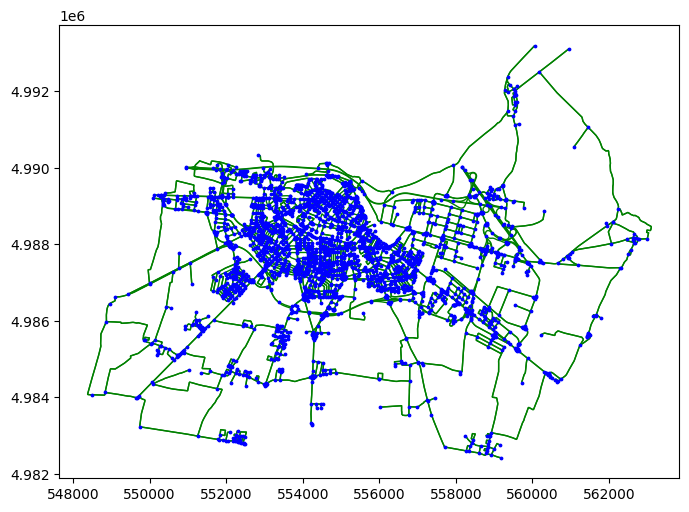

In [269]:
# Check the data
f, ax = plt.subplots(figsize=(8,8))
nodes_gnn.plot(ax=ax, color='blue', markersize=3, zorder=2)
edges_gnn.plot(ax=ax, linewidth= 1, edgecolor= 'green', zorder=1)

In [273]:
# Preprocess the data and prepare the dataset

X = nodes_gnn.drop(columns=['geometry', 'railway', 'highway'])
X = np.array(X.values)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled.shape

(3231, 6)

In [274]:
edges_gnn.columns

Index(['u', 'v', 'key', 'osmid', 'oneway', 'reversed', 'length', 'bridge',
       'speed_kph', 'travel_time', 'junction', 'tunnel', 'access', 'edge_bc',
       'traffic_lights', 'traffic_center', 'traffic_speed', 'traffic_time',
       'geometry'],
      dtype='object')

In [275]:
nodes_gnn['osmid']

0          92972680
1         298033861
2          92972786
3          92975190
4         462186611
           ...     
3226    11902376451
3227    11902376457
3228    11922074615
3229    12029039004
3230    12353647376
Name: osmid, Length: 3231, dtype: int64

In [276]:
Y = edges_gnn['traffic_speed'].values
Y = np.array(Y)
# Prepare edge index 
node_to_id = {}
for i, node in enumerate(nodes_gnn['osmid'].values):
    node_to_id[node] = i

start_node = [node_to_id[i] for i in edges_gnn['u'].values]
end_node = [node_to_id[i] for i in edges_gnn['v'].values]
start = torch.tensor(start_node, dtype=torch.long)
end = torch.tensor(end_node, dtype=torch.long)
edge_index = torch.stack([start, end], dim=0)

In [277]:
# Create dataset for edge regression
class CremonaDataset(InMemoryDataset):
    def __init__(self, edge_index, x, y, pre_transform = None , transform=None):
        super(CremonaDataset, self).__init__('.', transform, None, None)
        
        # Create data object
        data = Data(x=torch.FloatTensor(x), 
                   y=torch.FloatTensor(y), 
                   edge_index=edge_index)
        
        # Set number of nodes and features
        data.num_nodes = x.shape[0]
        data.num_features = x.shape[1]
        data.num_edges = edge_index.shape[1]
        
        # Split data into train/val/test sets (70%/15%/15%)
        np.random.seed(0)
        n_nodes = data.num_nodes
        n_edges = data.num_edges
        indices = np.random.permutation(n_edges)
        #print(n_nodes) #debug
        
        train_idx = indices[:int(0.7 * n_edges)]
        #print(len(train_idx)) #debug
        val_idx = indices[int(0.7 * n_edges):int(0.85 * n_edges)]
        test_idx = indices[int(0.85 * n_edges):]
        
        # Create masks
        train_mask = torch.zeros(n_edges, dtype=torch.bool)
        val_mask = torch.zeros(n_edges, dtype=torch.bool)
        test_mask = torch.zeros(n_edges, dtype=torch.bool)
        
        train_mask[train_idx] = True
        val_mask[val_idx] = True
        test_mask[test_idx] = True
        
        data.train_mask = train_mask    #size is still all nodes but only True for train nodes
        data.val_mask = val_mask
        data.test_mask = test_mask
        
        self.data, self.slices = self.collate([data])
        
        print("Dataset created with {} nodes".format(data.num_nodes), "and {} edges".format(edge_index.shape[1]))
    
    
# Set torch device to cuda if available or else cpu
#device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

dataset = CremonaDataset(edge_index, X_scaled, Y)
data = dataset[0].to(device)

cpu
Dataset created with 3231 nodes and 6930 edges


In [278]:
# Define hyperparameters
HIDDEN_DIM = 64
LR = 0.01


class GATv2(torch.nn.Module):
    def __init__(self, hidden_layer, data, output_dim = 1 , heads=4):
        super(GATv2, self).__init__()
        self.gat1 = GATv2Conv(data.num_features, hidden_layer, heads=heads)
        self.gat2 = GATv2Conv(hidden_layer*heads, hidden_layer, heads=1)
        self.linear = nn.Linear(hidden_layer*2, output_dim)

    def forward(self, data):
        # Get node features and edge index
        x, edge_index = data.x, data.edge_index
        
        # First layer
        out= self.gat1(x, edge_index)
        out = F.elu(out)
        out = F.dropout(out, p= 0.5, training=self.training)
        
        # Second layer
        out = self.gat2(out, edge_index)
        
        src, dst = edge_index   # src and dst are the start and end nodes of the edges
        out = torch.concat((out[src], out[dst]), dim=1)  # Concatenate the features of the start and end nodes
        
        # Final layer
        out = self.linear(out)
        
        
        return out

# Initialise GCN model instance
model = GATv2(HIDDEN_DIM, data).to(device) 
print(model)

GATv2(
  (gat1): GATv2Conv(6, 64, heads=4)
  (gat2): GATv2Conv(256, 64, heads=1)
  (linear): Linear(in_features=128, out_features=1, bias=True)
)


In [279]:
# Define loss and optimizer
criterion = nn.MSELoss()  # Mean Squared Error for regression
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=20)

# Training function
def train():
    model.train()
    optimizer.zero_grad()
    # Forward pass
    out = model(data)
    # Compute loss (only on training nodes)
    loss = criterion(out[data.train_mask].squeeze(), data.y[data.train_mask]) # squeeze() to remove extra dimension
    # Backward pass
    loss.backward()
    optimizer.step()
    return loss.item()

# Evaluation function
def evaluate(mask):
    model.eval()
    with torch.no_grad():
        out = model(data)
        pred = out[mask].squeeze()
        true = data.y[mask]
        loss = criterion(pred, true)
    return loss.item()

In [280]:
out = model(data)
out[data.train_mask].squeeze()

tensor([ 0.1075,  0.1274, -0.0473,  ..., -0.0379, -0.3373, -0.2192],
       grad_fn=<SqueezeBackward0>)

In [281]:
# Training loop
EPOCHS = 1000
best_loss = float('inf')
early_stop_counter = 0
early_stop_patience = 30
train_losses, val_losses = [], []

print(f"Starting training on {device}...")
for epoch in range(1, EPOCHS + 1):
    # Train
    train_loss = train()
    train_losses.append(train_loss)
    
    # Evaluate on validation set
    val_loss = evaluate(data.val_mask)
    val_losses.append(val_loss)
    
    # Adjust learning rate
    scheduler.step(val_loss)
    
    # Early stopping check
    if val_loss < best_loss:
        best_loss = val_loss
        torch.save(model.state_dict(), 'best_CR_gat.pt')
        early_stop_counter = 0
    else:
        early_stop_counter += 1
        
        
    
    # Print progress
    if epoch % 10 == 0:
        test_loss  = evaluate(data.test_mask)
        print(f'Epoch: {epoch:03d}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, '
              f'Test Loss: {test_loss:.4f}, ')
        
    # Check for early stopping
    if early_stop_counter >= early_stop_patience:
        print(f"Early stopping at epoch {epoch}")
        break

Starting training on cpu...
Epoch: 010, Train Loss: 344.1662, Val Loss: 151.4215, Test Loss: 155.8818, 
Epoch: 020, Train Loss: 114.9203, Val Loss: 81.1195, Test Loss: 82.0854, 
Epoch: 030, Train Loss: 97.3975, Val Loss: 93.0031, Test Loss: 93.7525, 
Epoch: 040, Train Loss: 100.5687, Val Loss: 74.9070, Test Loss: 75.1531, 
Epoch: 050, Train Loss: 92.9171, Val Loss: 72.8010, Test Loss: 73.6193, 
Epoch: 060, Train Loss: 91.5866, Val Loss: 73.8242, Test Loss: 74.3998, 
Epoch: 070, Train Loss: 89.0272, Val Loss: 70.0280, Test Loss: 71.0086, 
Epoch: 080, Train Loss: 86.4555, Val Loss: 68.9865, Test Loss: 69.8732, 
Epoch: 090, Train Loss: 86.3380, Val Loss: 68.0603, Test Loss: 69.0552, 
Epoch: 100, Train Loss: 84.6101, Val Loss: 67.0791, Test Loss: 67.4291, 
Epoch: 110, Train Loss: 82.9791, Val Loss: 65.1621, Test Loss: 66.5084, 
Epoch: 120, Train Loss: 80.4126, Val Loss: 63.6953, Test Loss: 65.3411, 
Epoch: 130, Train Loss: 79.0061, Val Loss: 62.5150, Test Loss: 64.3135, 
Epoch: 140, Train 

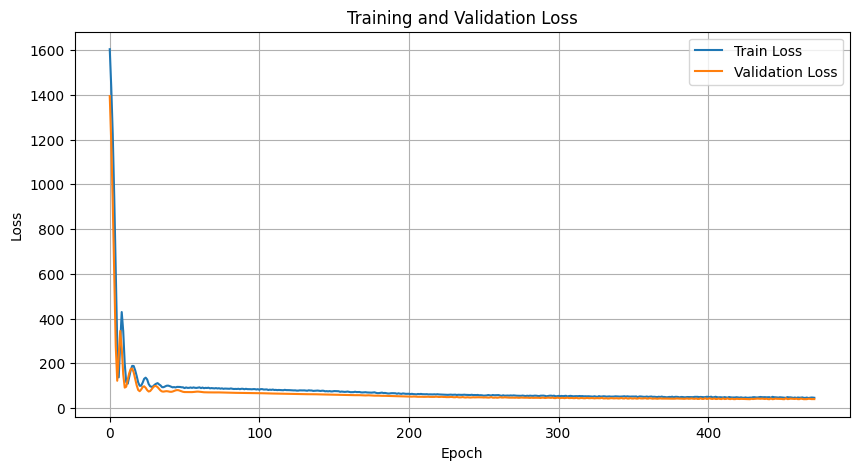

In [282]:
# Plot training and validation loss
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid()

In [283]:
# Load best model for final evaluation
model = GATv2(HIDDEN_DIM, data).to(device)
model.load_state_dict(torch.load('best_CR_gat.pt'))
test_loss = evaluate(data.test_mask)
print(f'Final Test Results - Loss: {test_loss:.4f}')

Final Test Results - Loss: 43.1241


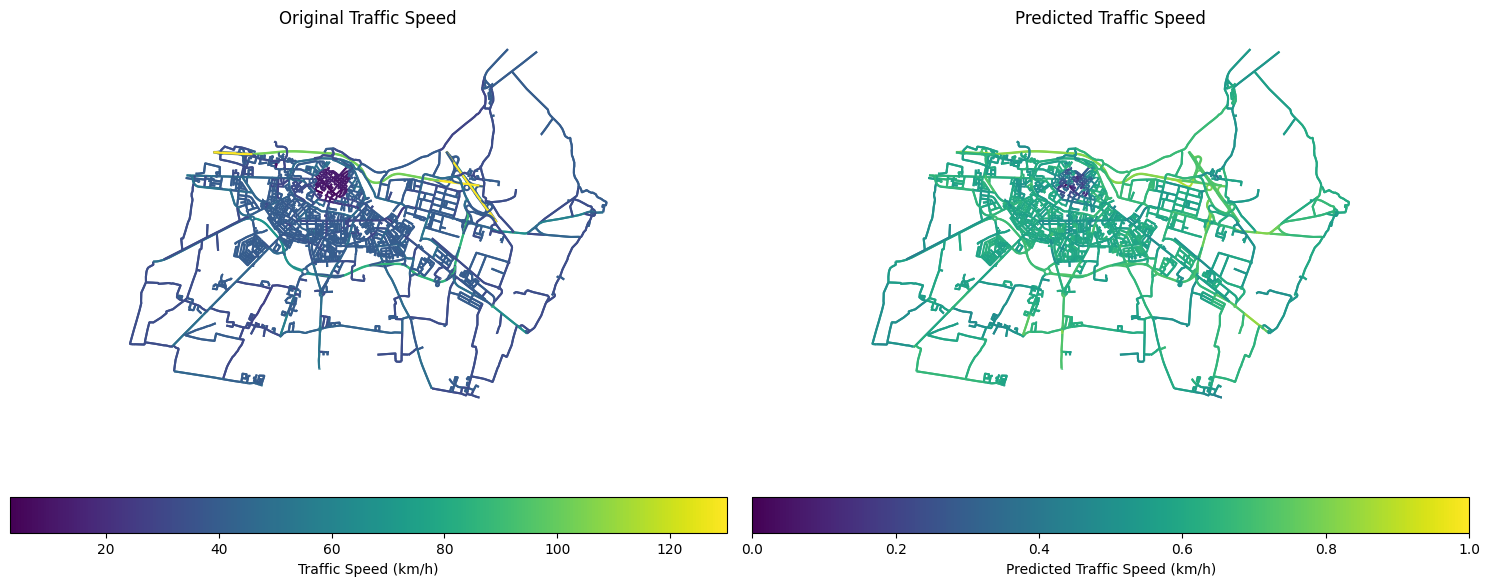

In [284]:
# Generate predictions for all nodes
model.eval()
with torch.no_grad():
    predictions = model(data).squeeze().cpu().numpy()

# Normalize the predictions
scaler = MinMaxScaler()
predictions = scaler.fit_transform(predictions.reshape(-1, 1))
    
# Add predictions back to the geodataframe for visualization
edges_gnn['predictions'] = predictions


#Visualize the predictions

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot the original traffic speed
edges_gnn.plot(column='traffic_speed', ax=ax1, legend=True, cmap='viridis', legend_kwds={
    'label': "Traffic Speed (km/h)",
    'orientation': "horizontal"
})
ax1.set_title('Original Traffic Speed')
ax1.set_axis_off()

# Plot the predicted traffic speed
edges_gnn.plot(column='predictions', ax=ax2, legend=True, cmap='viridis', legend_kwds={
    'label': "Predicted Traffic Speed (km/h)",
    'orientation': "horizontal"
})
ax2.set_title('Predicted Traffic Speed')
ax2.set_axis_off()

plt.tight_layout()
plt.show()

# Next steps I would like to try a Graph Transformer and see how it works
## Instead of a GNN, let's try a Graph Transformer
Let's start with TransformerConv, which should still be very similar to GNNs since its attention mechanism is based on the edges

In [285]:
# Define hyperparameters
HIDDEN_DIM = 64
LR = 0.01
EPOCHS = 1000

class GT(torch.nn.Module):
    def __init__(self, hidden_layer, data, output_dim = 1 , heads=4):
        super(GT, self).__init__()
        self.transf1 = torch_geometric.nn.TransformerConv(data.num_features, hidden_layer, heads=heads, concat=True, dropout=0.5)
        self.layernorm1 = torch.nn.LayerNorm(hidden_layer*heads)
        
        self.transf2 = torch_geometric.nn.TransformerConv(hidden_layer*heads, hidden_layer, heads= heads, concat=False) 
        # No concat here because it is the last layer, which means that it will average the heads
        
        
        self.linear = nn.Linear(hidden_layer*2, output_dim)

    def forward(self, data):
        # Get node features and edge index
        x, edge_index = data.x, data.edge_index
        
        # First layer
        out = self.transf1(x, edge_index)
        out = self.layernorm1(out)
        out = F.relu(out)
        
        # Second layer
        out = self.transf2(out, edge_index) # No Norm and activation function because it is the last layer
        
        
        src, dst = edge_index   # src and dst are the start and end nodes of the edges
        out = torch.concat((out[src], out[dst]), dim=1)  # Concatenate the features of the start and end nodes
        
        # Final layer
        out = self.linear(out)    
        return out
    
    def reset_parameters(self):
        self.transf1.reset_parameters()
        self.transf2.reset_parameters()
        self.layernorm1.reset_parameters()
        
# Initialise GT model instance
model = GT(HIDDEN_DIM, data).to(device)
print(model)

GT(
  (transf1): TransformerConv(6, 64, heads=4)
  (layernorm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  (transf2): TransformerConv(256, 64, heads=4)
  (linear): Linear(in_features=128, out_features=1, bias=True)
)


In [286]:
# Define loss and optimizer
criterion = nn.MSELoss()  # Mean Squared Error for regression
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=20)


def train_tr():
    model.train()
    optimizer.zero_grad()
    # Forward pass
    out = model(data)
    # Compute loss (only on training nodes)
    loss = criterion(out[data.train_mask].squeeze(), data.y[data.train_mask]) # squeeze() to remove extra dimension
    # Backward pass
    loss.backward()
    optimizer.step()
    return loss.item()

def evaluate_tr(mask):
    model.eval()
    with torch.no_grad():
        out = model(data)
        pred = out[mask].squeeze()
        true = data.y[mask]
        loss = criterion(pred, true)
    return loss.item()

In [287]:
out = model(data)
out[data.train_mask].squeeze()

tensor([-0.1989, -0.1407, -0.2328,  ...,  0.0538,  0.0815, -0.0263],
       grad_fn=<SqueezeBackward0>)

In [288]:
# Training loop
best_loss = float('inf')
early_stop_counter = 0
early_stop_patience = 30
train_losses, val_losses = [], []


print(f"Starting training on {device}...")
model.reset_parameters()
for epoch in range(1, EPOCHS + 1):
    # Train
    train_loss = train_tr()
    train_losses.append(train_loss)
    
    # Evaluate on validation set
    val_loss = evaluate_tr(data.val_mask)
    val_losses.append(val_loss)
    
    # Adjust learning rate
    scheduler.step(val_loss)
    
    # Early stopping check
    if val_loss < best_loss:
        best_loss = val_loss
        torch.save(model.state_dict(), 'best_CR_gt.pt')
        early_stop_counter = 0
    else:
        early_stop_counter += 1
        
        
    
    # Print progress
    if epoch % 10 == 0:
        test_loss  = evaluate_tr(data.test_mask)
        print(f'Epoch: {epoch:03d}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, '
              f'Test Loss: {test_loss:.4f}, ')
        
    # Check for early stopping
    if early_stop_counter >= early_stop_patience:
        print(f"Early stopping at epoch {epoch}")
        break

Starting training on cpu...
Epoch: 010, Train Loss: 170.2827, Val Loss: 196.9855, Test Loss: 199.6883, 
Epoch: 020, Train Loss: 136.5776, Val Loss: 103.6174, Test Loss: 102.8155, 
Epoch: 030, Train Loss: 81.3944, Val Loss: 77.0054, Test Loss: 75.9235, 
Epoch: 040, Train Loss: 87.4476, Val Loss: 64.6746, Test Loss: 64.5948, 
Epoch: 050, Train Loss: 75.8052, Val Loss: 61.5766, Test Loss: 61.3807, 
Epoch: 060, Train Loss: 74.9235, Val Loss: 64.0799, Test Loss: 63.6941, 
Epoch: 070, Train Loss: 72.4112, Val Loss: 62.7597, Test Loss: 62.4883, 
Epoch: 080, Train Loss: 70.1433, Val Loss: 60.1777, Test Loss: 59.8969, 
Epoch: 090, Train Loss: 68.8463, Val Loss: 57.9975, Test Loss: 57.7384, 
Epoch: 100, Train Loss: 66.2027, Val Loss: 56.9001, Test Loss: 56.4905, 
Epoch: 110, Train Loss: 65.4468, Val Loss: 55.4145, Test Loss: 55.2242, 
Epoch: 120, Train Loss: 62.8463, Val Loss: 54.1452, Test Loss: 53.9934, 
Epoch: 130, Train Loss: 61.1740, Val Loss: 53.3322, Test Loss: 53.2372, 
Epoch: 140, Train

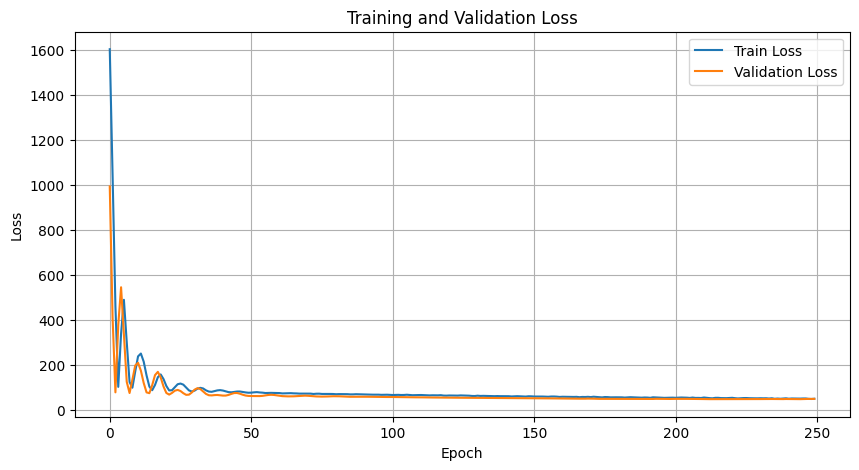

In [289]:
# Plot training and validation loss
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid()


In [290]:
# Load best model for final evaluation
model.load_state_dict(torch.load('best_CR_gt.pt'))
test_loss = evaluate_tr(data.test_mask)
print(f'Final Test Results - Loss: {test_loss:.4f}')

Final Test Results - Loss: 48.4273


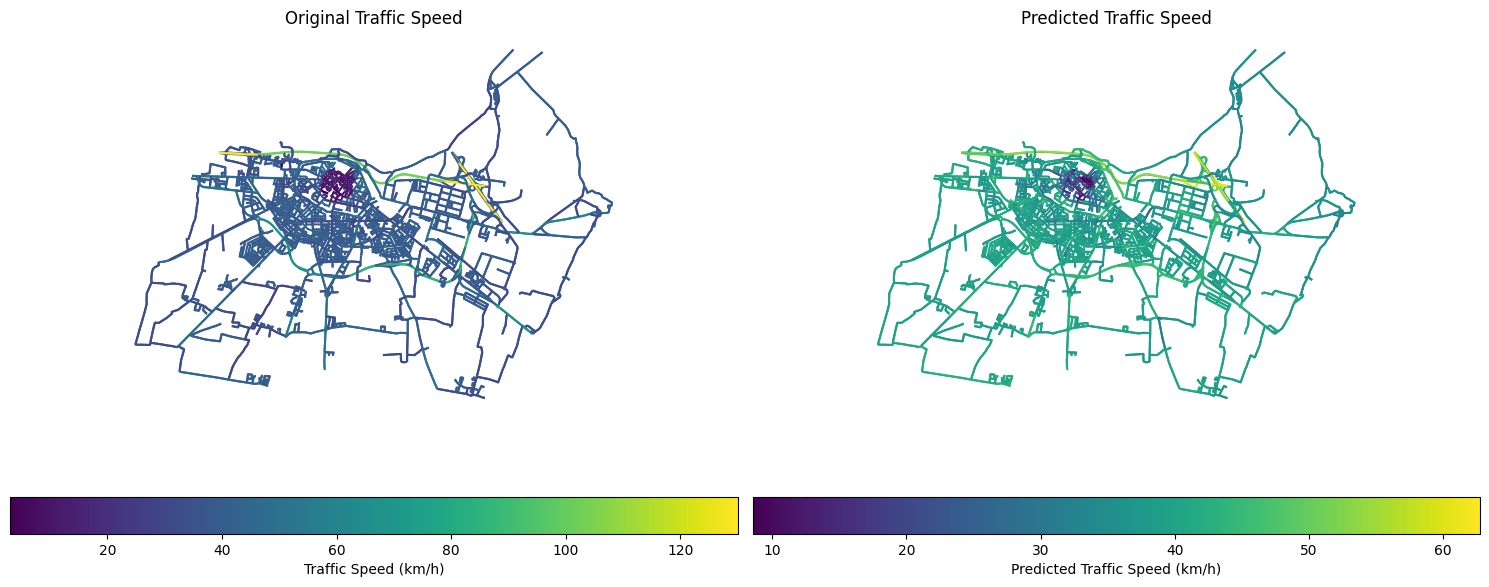

In [291]:
# Generate predictions for all nodes
model.eval()
with torch.no_grad():
    predictions = model(data).squeeze().cpu().numpy()
# Add predictions back to the geodataframe for visualization
edges_gnn['predictions_tr'] = predictions
#Visualize the predictions
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
# Plot the original traffic speed
edges_gnn.plot(column='traffic_speed', ax=ax1, legend=True, cmap='viridis', legend_kwds={
    'label': "Traffic Speed (km/h)",
    'orientation': "horizontal"
})
ax1.set_title('Original Traffic Speed')
ax1.set_axis_off()
# Plot the predicted traffic speed
edges_gnn.plot(column='predictions_tr', ax=ax2, legend=True, cmap='viridis', legend_kwds={
    'label': "Predicted Traffic Speed (km/h)",
    'orientation': "horizontal"
})
ax2.set_title('Predicted Traffic Speed')
ax2.set_axis_off()
plt.tight_layout()
plt.show()

Skipping field highway: unsupported OGR type: 5
Skipping field lanes: unsupported OGR type: 5
Skipping field name: unsupported OGR type: 5
Skipping field maxspeed: unsupported OGR type: 5
Skipping field bridge: unsupported OGR type: 5


<Axes: >

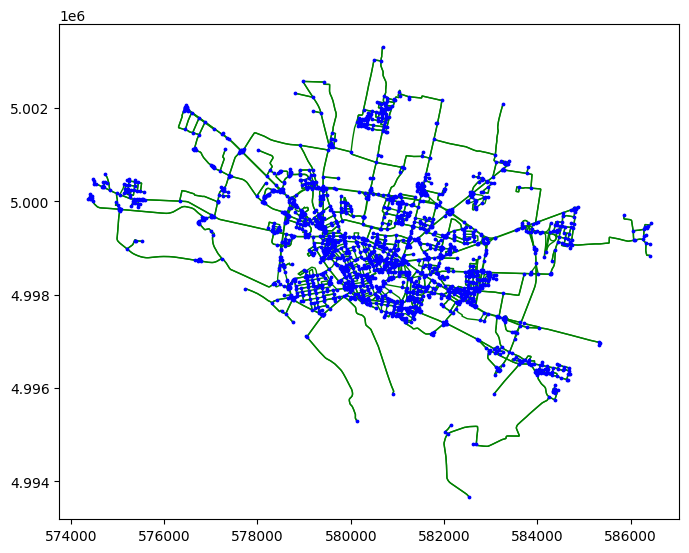

In [293]:
# Load new data
nodes_gnn2 = gpd.read_file('nodes_CR.geojson')
edges_gnn2 = gpd.read_file('edges_CR.geojson')
#plot
f, ax = plt.subplots(figsize=(8,8))
nodes_gnn2.plot(ax=ax, color='blue', markersize=3, zorder=2)
edges_gnn2.plot(ax=ax, linewidth= 1, edgecolor= 'green', zorder=1)


In [294]:
# Check the data
nodes_gnn2.head()

,osmid,y,x,street_count,highway,junction,bc,traffic_lights,geometry
0,249617125,5.000033e+06,578681.931488,3,None,None,0.221561,False,POINT (5.79e+05 5e+06)
1,302402633,4.999980e+06,578679.421611,3,None,None,0.221585,False,POINT (5.79e+05 5e+06)
2,249617128,4.999968e+06,578742.690104,3,None,None,0.231506,False,POINT (5.79e+05 5e+06)
3,302402587,4.999994e+06,578765.527141,3,None,None,0.246801,False,POINT (5.79e+05 5e+06)
4,302415503,4.999956e+06,578784.130629,3,None,None,0.288959,False,POINT (5.79e+05 5e+06)


In [295]:
# Preprocess the data and prepare the dataset
X2 = nodes_gnn2.drop(columns=['geometry', 'junction', 'highway'])
X2 = np.array(X2.values)
scaler = StandardScaler()
X2_scaled = scaler.fit_transform(X2)
X2_scaled.shape

(2280, 6)

In [296]:
# Prepare edge index
node_to_id2 = {}
for i, node in enumerate(nodes_gnn2['osmid'].values):
    node_to_id2[node] = i
start_node_pc = [node_to_id2[i] for i in edges_gnn2['u'].values]
end_node_pc = [node_to_id2[i] for i in edges_gnn2['v'].values]
start_pc = torch.tensor(start_node_pc, dtype=torch.long)
end_pc = torch.tensor(end_node_pc, dtype=torch.long)
edge_index2 = torch.stack([start_pc, end_pc], dim=0)

Y2 = edges_gnn2['traffic_speed'].values
Y2 = np.array(Y2)

In [297]:
# Create dataset for edge regression
data2 = CremonaDataset(edge_index2, X2_scaled, Y2)

Dataset created with 2280 nodes and 4786 edges


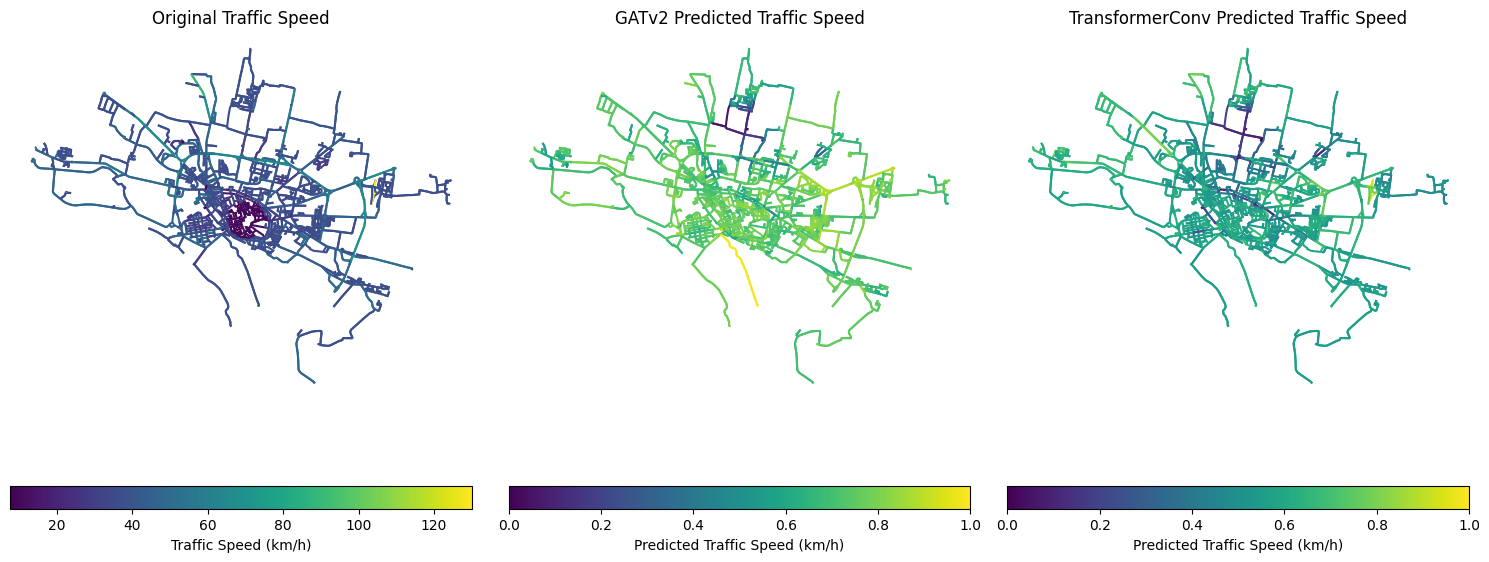

In [298]:
# Compare the models:
gat_model = GATv2(HIDDEN_DIM, data2[0]).to(device)
gat_model.load_state_dict(torch.load('best_CR_gat.pt'))
gt_model = GT(HIDDEN_DIM, data2[0]).to(device)
gt_model.load_state_dict(torch.load('best_CR_gt.pt'))

gat_model.eval()
gt_model.eval()
with torch.no_grad():
    gat_predictions = gat_model(data2[0]).squeeze().cpu().numpy()
    gt_predictions = gt_model(data2[0]).squeeze().cpu().numpy()
    
# Normalize the predictions
scaler = MinMaxScaler()
gat_predictions = scaler.fit_transform(gat_predictions.reshape(-1, 1))
gt_predictions = scaler.fit_transform(gt_predictions.reshape(-1, 1))

# Add predictions back to the geodataframe for visualization
edges_gnn2['gat_predictions'] = gat_predictions
edges_gnn2['gt_predictions'] = gt_predictions

# Visualize the predictions
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 6))
# Plot the original traffic speed
edges_gnn2.plot(column='traffic_speed', ax=ax1, legend=True, cmap='viridis', legend_kwds={
    'label': "Traffic Speed (km/h)",
    'orientation': "horizontal"
})
ax1.set_title('Original Traffic Speed')
ax1.set_axis_off()
# Plot the GAT predictions
edges_gnn2.plot(column='gat_predictions', ax=ax2, legend=True, cmap='viridis', legend_kwds={
    'label': "Predicted Traffic Speed (km/h)",
    'orientation': "horizontal"
})
ax2.set_title('GATv2 Predicted Traffic Speed')
ax2.set_axis_off()
# Plot the GT predictions
edges_gnn2.plot(column='gt_predictions', ax=ax3, legend=True, cmap='viridis', legend_kwds={
    'label': "Predicted Traffic Speed (km/h)",
    'orientation': "horizontal"
})
ax3.set_title('TransformerConv Predicted Traffic Speed')
ax3.set_axis_off()
plt.tight_layout()
plt.show()

## Don't stop me now, I'm having such a good time 
### I want to try a proper transformer model, like the GPS 

In [299]:
import argparse
import os.path as osp
from typing import Any, Dict, Optional

import torch
from torch.nn import (
    BatchNorm1d,
    Embedding,
    Linear,
    ModuleList,
    ReLU,
    Sequential,
)
from torch.optim.lr_scheduler import ReduceLROnPlateau

import torch_geometric.transforms as T
from torch_geometric.datasets import ZINC
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GINConv, GPSConv, global_add_pool
from torch_geometric.nn.attention import PerformerAttention

In [300]:
# Preprocess the data and prepare the dataset
transform = T.AddRandomWalkPE( walk_length= 20, attr_name= 'pe')
transform2 = T.AddLaplacianEigenvectorPE(k = 20, attr_name= 'pe')
data = Data(x = torch.FloatTensor(X_scaled), y = torch.FloatTensor(Y), edge_index = edge_index )
data = transform2(data)

data.num_edges

6930

In [301]:
 # Split data into train/val/test sets (70%/15%/15%)
np.random.seed(0)
        
n_edges = data.num_edges
indices = np.random.permutation(n_edges)
        
train_idx = indices[:int(0.7 * n_edges)]
print(len(train_idx)) #debug
val_idx = indices[int(0.7 * n_edges):int(0.85 * n_edges)]
print(len(val_idx)) #debug
test_idx = indices[int(0.85 * n_edges):]
print(len(test_idx)) #debug
        
# Create masks
train_mask = torch.zeros(n_edges, dtype=torch.bool)
val_mask = torch.zeros(n_edges, dtype=torch.bool)
test_mask = torch.zeros(n_edges, dtype=torch.bool)
    
train_mask[train_idx] = True
val_mask[val_idx] = True
test_mask[test_idx] = True
        
data.train_mask = train_mask    #size is still all nodes but only True for train nodes
data.val_mask = val_mask
data.test_mask = test_mask

data.to(device)

4851
1039
1040


Data(x=[3231, 6], edge_index=[2, 6930], y=[6930], pe=[3231, 20], train_mask=[6930], val_mask=[6930], test_mask=[6930])

In [302]:
class RedrawProjection:
    def __init__(self, model: torch.nn.Module,
                redraw_interval: Optional[int] = None):
        self.model = model
        self.redraw_interval = redraw_interval
        self.num_last_redraw = 0

    def redraw_projections(self):
        if not self.model.training or self.redraw_interval is None:
            return
        if self.num_last_redraw >= self.redraw_interval:
            fast_attentions = [
                module for module in self.model.modules()
                if isinstance(module, PerformerAttention)
            ]
            for fast_attention in fast_attentions:
                fast_attention.redraw_projection_matrix()
            self.num_last_redraw = 0
            return
        self.num_last_redraw += 1



In [303]:
class GPS(torch.nn.Module):
    def __init__(self, channels: int, pe_dim: int, num_layers: int,
                 attn_type: str = 'performer', dropout: float = 0.0):
        super().__init__()

        self.node_emb = Linear(data.x.shape[1], channels - pe_dim)
        self.pe_lin = Linear(20, pe_dim)
        self.pe_norm = BatchNorm1d(20)

        self.convs = ModuleList()
        for _ in range(num_layers):
            nn = Sequential(
                Linear(channels, channels),
                ReLU(),
                Linear(channels, channels),
            )
            conv = GPSConv(channels, GINConv(nn), heads=4,
                           attn_type=attn_type, dropout=dropout)
            self.convs.append(conv)

        self.mlp = Sequential(
            Linear(2* channels, channels),
            ReLU(),
            Linear(channels, 1)
            
        )
        self.redraw_projection = RedrawProjection(
            self.convs,
            redraw_interval=1000 if attn_type == 'performer' else None)

    def forward(self, x, pe, edge_index):
        x_pe = self.pe_norm(pe)
        x = torch.cat((self.node_emb(x), self.pe_lin(x_pe)), 1)
        

        for conv in self.convs:
            x = conv(x, edge_index)
        
        # Edge-level prediction
        src, dst = edge_index
        x = torch.cat((x[src], x[dst]), dim=1)
        
        x = self.mlp(x)
        return x

In [304]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = GPS(channels= 64, pe_dim=8, num_layers=2, attn_type= 'performer',
            dropout= 0.5).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=20,
                              min_lr=0.00001)

In [305]:
model

GPS(
  (node_emb): Linear(in_features=6, out_features=56, bias=True)
  (pe_lin): Linear(in_features=20, out_features=8, bias=True)
  (pe_norm): BatchNorm1d(20, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (convs): ModuleList(
    (0-1): 2 x GPSConv(64, conv=GINConv(nn=Sequential(
      (0): Linear(in_features=64, out_features=64, bias=True)
      (1): ReLU()
      (2): Linear(in_features=64, out_features=64, bias=True)
    )), heads=4, attn_type=performer)
  )
  (mlp): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=1, bias=True)
  )
)

In [306]:
def train(data):
    model.train()
    optimizer.zero_grad()
    model.redraw_projection.redraw_projections()
    out = model(data.x, data.pe, data.edge_index)
    pred = out[data.train_mask].squeeze()
    loss = criterion(out[data.train_mask].squeeze(), data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()

def evaluate(data, mask):
    model.eval()
    with torch.no_grad():
        out = model(data.x, data.pe, data.edge_index)
        pred = out[mask].squeeze()
        true = data.y[mask]
        loss = criterion(pred, true)
    return loss.item()

In [307]:
out = model(data.x, data.pe, data.edge_index)
out[data.val_mask].squeeze().size()

torch.Size([1039])

In [308]:
# Training loop
EPOCHS = 500

best_loss = float('inf')
early_stop_counter = 0
early_stop_patience = 30
train_losses, val_losses = [], []

print(f"Starting training on {device}...")

for epoch in range(1, EPOCHS + 1):
    # Train
    train_loss = train(data)
    train_losses.append(train_loss)
    
    # Evaluate on validation set
    val_loss = evaluate(data, data.val_mask)
    val_losses.append(val_loss)
    
    # Adjust learning rate
    scheduler.step(val_loss)
    
    # Early stopping check
    if val_loss < best_loss:
        best_loss = val_loss
        torch.save(model.state_dict(), 'best_CR_gps.pt')
        early_stop_counter = 0
    else:
        early_stop_counter += 1
        
        
    
    # Print progress
    if epoch % 10 == 0:
        test_loss  = evaluate(data, data.test_mask)
        print(f'Epoch: {epoch:03d}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, '
              f'Test Loss: {test_loss:.4f}, ')
        
    # Check for early stopping
    if early_stop_counter >= early_stop_patience:
        print(f"Early stopping at epoch {epoch}")
        break

Starting training on cpu...
Epoch: 010, Train Loss: 1542.1414, Val Loss: 1461.4457, Test Loss: 1475.9049, 
Epoch: 020, Train Loss: 1441.3892, Val Loss: 1225.9818, Test Loss: 1238.1957, 
Epoch: 030, Train Loss: 1279.4009, Val Loss: 1012.8176, Test Loss: 1025.6288, 
Epoch: 040, Train Loss: 1043.7712, Val Loss: 891.3500, Test Loss: 904.1434, 
Epoch: 050, Train Loss: 772.2402, Val Loss: 788.0936, Test Loss: 797.4039, 
Epoch: 060, Train Loss: 504.2330, Val Loss: 601.4893, Test Loss: 609.9050, 
Epoch: 070, Train Loss: 283.5039, Val Loss: 378.0045, Test Loss: 391.6177, 
Epoch: 080, Train Loss: 141.4728, Val Loss: 290.9802, Test Loss: 308.1422, 
Epoch: 090, Train Loss: 78.2494, Val Loss: 171.6572, Test Loss: 183.8857, 
Epoch: 100, Train Loss: 59.2346, Val Loss: 134.2400, Test Loss: 143.7245, 
Epoch: 110, Train Loss: 52.9678, Val Loss: 99.8707, Test Loss: 113.0138, 
Epoch: 120, Train Loss: 48.3212, Val Loss: 79.2558, Test Loss: 88.0160, 
Epoch: 130, Train Loss: 47.1018, Val Loss: 58.0039, Test 

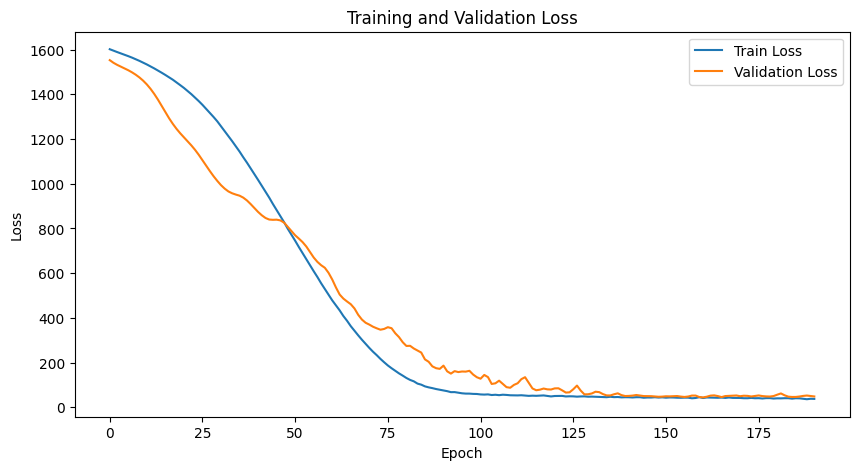

In [309]:
# Plot training and validation loss
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

In [310]:
# Load best model for final evaluation
model.load_state_dict(torch.load('best_CR_gps.pt'))
test_loss = evaluate(data, data.test_mask)
print(f'Final Test Results - Loss: {test_loss:.4f}')

Final Test Results - Loss: 52.5763


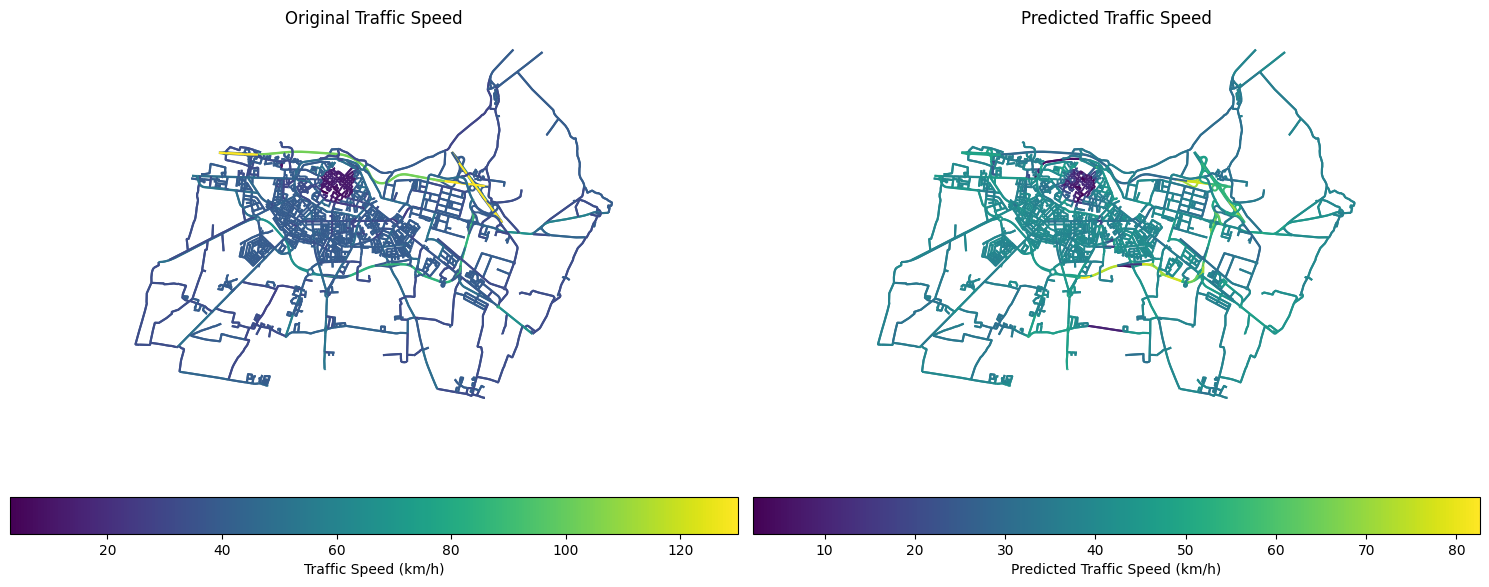

In [311]:
# Generate predictions for all nodes
model.eval()
with torch.no_grad():
    predictions = model(data.x, data.pe, data.edge_index).squeeze().cpu().numpy()
# Add predictions back to the geodataframe for visualization
edges_gnn['gps_predictions'] = predictions
#Visualize the predictions
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
# Plot the original traffic speed
edges_gnn.plot(column='traffic_speed', ax=ax1, legend=True, cmap='viridis', legend_kwds={
    'label': "Traffic Speed (km/h)",
    'orientation': "horizontal"
})
ax1.set_title('Original Traffic Speed')
ax1.set_axis_off()
# Plot the predicted traffic speed
edges_gnn.plot(column='gps_predictions', ax=ax2, legend=True, cmap='viridis', legend_kwds={
    'label': "Predicted Traffic Speed (km/h)",
    'orientation': "horizontal"
})
ax2.set_title('Predicted Traffic Speed')
ax2.set_axis_off()
plt.tight_layout()
plt.show()

In [312]:
data2 = Data(x = torch.FloatTensor(X2_scaled), y = torch.FloatTensor(Y2), edge_index = edge_index2 )
data2 = transform2(data2)
#set seed
torch.manual_seed(0)
idxs = torch.randperm(data2.num_edges)
ft_idx = idxs[:int(0.25 * data2.num_edges)]
ft_val_idx = idxs[int(0.25 * data2.num_edges):int(0.3 * data2.num_edges)]

data2.train_mask = torch.zeros(data2.num_edges, dtype=torch.bool)
data2.train_mask[ft_idx] = True
data2.val_mask = torch.zeros(data2.num_edges, dtype=torch.bool)
data2.val_mask[ft_val_idx] = True





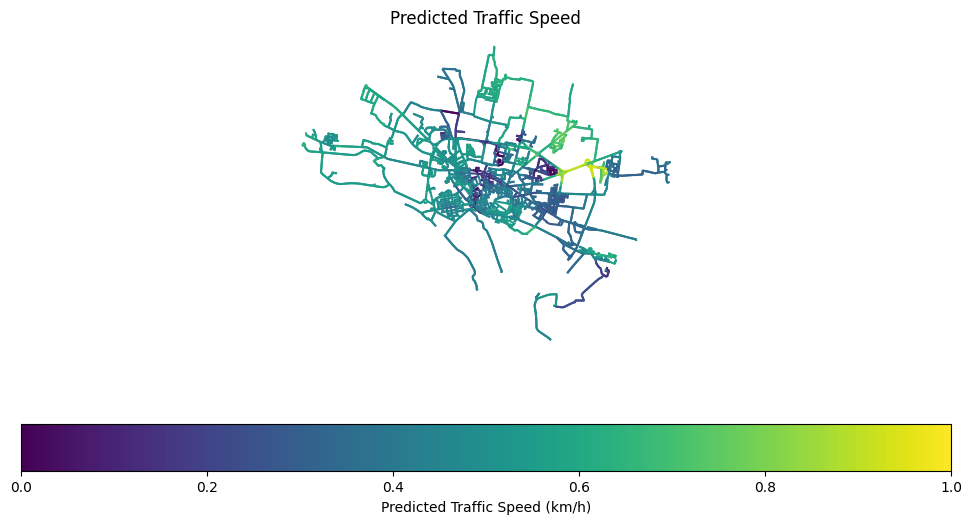

In [313]:
# predictions for the new data
model.eval()
with torch.no_grad():
    predictions_pc = model(data2.x, data2.pe, data2.edge_index).squeeze().cpu().numpy()
    
# Normalize the predictions
scaler = MinMaxScaler()
predictions_pc = scaler.fit_transform(predictions_pc.reshape(-1, 1))
# Add predictions back to the geodataframe for visualization
edges_gnn2['gps_predictions'] = predictions_pc
#Visualize the predictions
fig, ax = plt.subplots(1, 1, figsize=(12, 6))
# Plot the predicted traffic speed
edges_gnn2.plot(column='gps_predictions', ax=ax, legend=True, cmap='viridis', legend_kwds={
    'label': "Predicted Traffic Speed (km/h)",
    'orientation': "horizontal"
})
ax.set_title('Predicted Traffic Speed')
ax.set_axis_off()

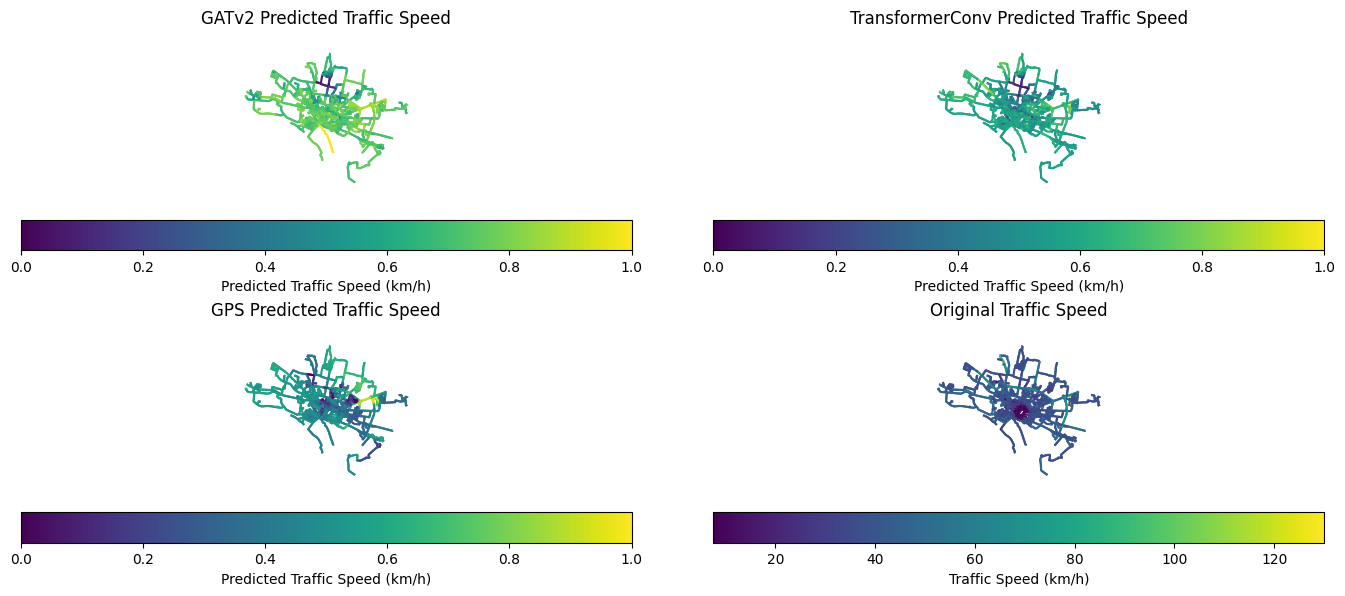

In [314]:
# compare the three models
fig, axs = plt.subplots(2, 2, figsize=(14, 6))
ax1, ax2, ax3, ax4 = axs.flatten()
# Plot the GAT predictions
edges_gnn2.plot(column='gat_predictions', ax=ax1, legend=True, cmap='viridis', legend_kwds={
    'label': "Predicted Traffic Speed (km/h)",
    'orientation': "horizontal"
})
ax1.set_title('GATv2 Predicted Traffic Speed')
ax1.set_axis_off()
# Plot the GT predictions
edges_gnn2.plot(column='gt_predictions', ax=ax2, legend=True, cmap='viridis', legend_kwds={
    'label': "Predicted Traffic Speed (km/h)",
    'orientation': "horizontal"
})
ax2.set_title('TransformerConv Predicted Traffic Speed')
ax2.set_axis_off()
# Plot the GPS predictions
edges_gnn2.plot(column='gps_predictions', ax=ax3, legend=True, cmap='viridis', legend_kwds={
    'label': "Predicted Traffic Speed (km/h)",
    'orientation': "horizontal"
})
ax3.set_title('GPS Predicted Traffic Speed')
ax3.set_axis_off()
# Plot the original traffic speed
edges_gnn2.plot(column='traffic_speed', ax=ax4, legend=True, cmap='viridis', legend_kwds={
    'label': "Traffic Speed (km/h)",
    'orientation': "horizontal"
})
ax4.set_title('Original Traffic Speed')
ax4.set_axis_off()
plt.tight_layout()
plt.show()

In [318]:
# Let's try to finetune the GPS model a bit more on the new data
# Load best model for final evaluation
model.load_state_dict(torch.load('best_CR_gps.pt'))

<All keys matched successfully>

In [316]:
# Training loop
EPOCHS = 50
best_loss = float('inf')
early_stop_counter = 0
early_stop_patience = 30
train_losses, val_losses = [], []
print(f"Starting training on {device}...")
for epoch in range(1, EPOCHS + 1):
    # Train
    train_loss = train(data2)
    train_losses.append(train_loss)
    
    # Evaluate on validation set
    val_loss = evaluate(data2, data2.val_mask)
    val_losses.append(val_loss)
    
    # Adjust learning rate
    scheduler.step(val_loss)
    
    # Early stopping check
    if val_loss < best_loss:
        best_loss = val_loss
        torch.save(model.state_dict(), 'best_gps_finetune.pt')
        early_stop_counter = 0
    else:
        early_stop_counter += 1
        
        
    
    # Print progress
    if epoch % 10 == 0:
        print(f'Epoch: {epoch:03d}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, ')
        
    # Check for early stopping
    if early_stop_counter >= early_stop_patience:
        print(f"Early stopping at epoch {epoch}")
        break

Starting training on cpu...
Epoch: 010, Train Loss: 96.7302, Val Loss: 391.9527, 
Epoch: 020, Train Loss: 78.4817, Val Loss: 155.1382, 
Epoch: 030, Train Loss: 73.9420, Val Loss: 88.7066, 
Epoch: 040, Train Loss: 68.4129, Val Loss: 83.3861, 
Epoch: 050, Train Loss: 67.4854, Val Loss: 83.2071, 


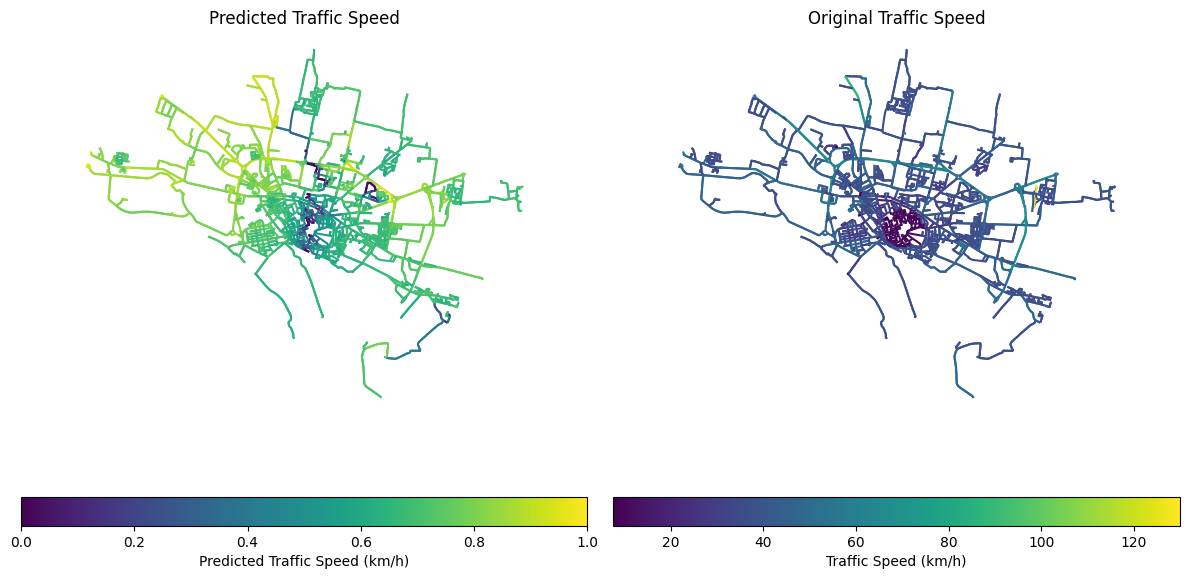

In [317]:
# Load best model for final evaluation
model.load_state_dict(torch.load('best_gps_finetune.pt'))

# Generate predictions for all nodes
model.eval()
with torch.no_grad():
    predictions_pc = model(data2.x, data2.pe, data2.edge_index).squeeze().cpu().numpy()
# Normalize the predictions
scaler = MinMaxScaler()
predictions_pc = scaler.fit_transform(predictions_pc.reshape(-1, 1))
# Add predictions back to the geodataframe for visualization
edges_gnn2['gps_predictions'] = predictions_pc
#Visualize the predictions
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
# Plot the predicted traffic speed
edges_gnn2.plot(column='gps_predictions', ax=ax1, legend=True, cmap='viridis', legend_kwds={
    'label': "Predicted Traffic Speed (km/h)",
    'orientation': "horizontal"
})
ax1.set_title('Predicted Traffic Speed')
ax1.set_axis_off()
# Plot the original traffic speed
edges_gnn2.plot(column='traffic_speed', ax=ax2, legend=True, cmap='viridis', legend_kwds={
    'label': "Traffic Speed (km/h)",
    'orientation': "horizontal"
})
ax2.set_title('Original Traffic Speed')
ax2.set_axis_off()
plt.tight_layout()
plt.show()
